In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import itertools

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Path to your CSV (adjust if needed)
CSV_PATH = r"c:/Users/jaina/OneDrive/Desktop/ML-Lab/synthetic_credit_card_approval.csv"
# For faster iteration you can set SUBSAMPLE to an int (e.g. 50000) or None to use the full data
SUBSAMPLE = 50000

In [3]:
# Load CSV dataset and optionally subsample
df = pd.read_csv(CSV_PATH)
if SUBSAMPLE is not None and SUBSAMPLE > 0 and SUBSAMPLE < len(df):
    df = df.sample(n=SUBSAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)
# Expecting columns: Num_Children, Group, Income, Own_Car, Own_Housing, Target
print("Raw CSV shape:", df.shape)
# Features and target
X = df.drop(columns=["Target"])
y = df["Target"]
class_names = [str(c) for c in sorted(y.unique())]
print("Features:", X.columns.tolist())
print("Target distribution:\n", y.value_counts(normalize=True))
X.head()

Raw CSV shape: (50000, 6)
Features: ['Num_Children', 'Group', 'Income', 'Own_Car', 'Own_Housing']
Target distribution:
 Target
0    0.61164
1    0.38836
Name: proportion, dtype: float64


,Num_Children,Group,Income,Own_Car,Own_Housing
0,2,1,46412,1,1
1,1,0,99722,0,0
2,2,0,30715,1,1
3,0,0,86796,0,1
4,0,1,64855,1,0


In [4]:
# Missing values?
print("Missing values per column:\n", X.isnull().sum())

# Define preprocessing: numeric and categorical
numeric_features = ["Num_Children", "Income"]
categorical_features = ["Group", "Own_Car", "Own_Housing"]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", cat_transformer, categorical_features)
])

# Train-test split on raw features (preprocessor will be fitted on train only)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
print("Train/Test raw shapes:", X_train_raw.shape, X_test_raw.shape)

# Fit preprocessor on train and transform both
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
# Convert sparse to dense if needed
if hasattr(X_train, 'toarray'):
    X_train = X_train.toarray()
if hasattr(X_test, 'toarray'):
    X_test = X_test.toarray()
print("Processed Train/Test shapes:", X_train.shape, X_test.shape)

Missing values per column:
 Num_Children    0
Group           0
Income          0
Own_Car         0
Own_Housing     0
dtype: int64
Train/Test raw shapes: (35000, 5) (15000, 5)
Processed Train/Test shapes: (35000, 8) (15000, 8)


In [5]:
# (a) PCA with 2 components for visualization (fit on processed train)
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = pca_2.fit_transform(X_train)
X_test_pca2 = pca_2.transform(X_test)

print("Explained variance ratio (2 components):", pca_2.explained_variance_ratio_)
print("Total explained variance (2 components):", pca_2.explained_variance_ratio_.sum())

# (b) PCA to capture 95% variance
pca_95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca95 = pca_95.fit_transform(X_train)
X_test_pca95 = pca_95.transform(X_test)

print("Number of components to capture 95% variance:", pca_95.n_components_)
print("Explained variance ratio sum:", pca_95.explained_variance_ratio_.sum())

Explained variance ratio (2 components): [0.32634077 0.29403097]
Total explained variance (2 components): 0.6203717410985194
Number of components to capture 95% variance: 5
Explained variance ratio sum: 0.9999999999999999


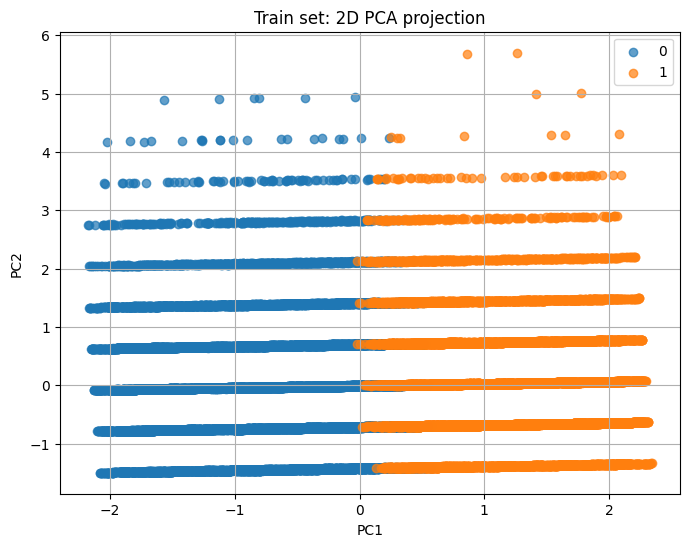

In [6]:
plt.figure(figsize=(8,6))
for label in np.unique(y_train):
    idx = np.where(y_train == label)
    plt.scatter(X_train_pca2[idx, 0], X_train_pca2[idx, 1], label=label, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Train set: 2D PCA projection")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# SVM configurations to test
svm_configs = {
    "linear_orig": SVC(kernel="linear", C=1.0, probability=True, random_state=RANDOM_STATE),
    "rbf_orig": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE),
    "rbf_pca95": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE),
    "rbf_pca2": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE),
}

In [8]:
results = []

# Helper to select the correct datasets
def get_data_for_key(key):
    if key.endswith("_orig"):
        return X_train, X_test
    elif key.endswith("_pca95"):
        return X_train_pca95, X_test_pca95
    elif key.endswith("_pca2"):
        return X_train_pca2, X_test_pca2
    else:
        raise ValueError(key)

for name, model in svm_configs.items():
    Xtr, Xte = get_data_for_key(name)
    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0
    
    t0 = time.time()
    y_pred = model.predict(Xte)
    predict_time = time.time() - t0
    
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    
    results.append({
        "model": name,
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "train_time_s": train_time,
        "predict_time_s": predict_time,
        "n_features": Xtr.shape[1]
    })
    
    print(f"{name}: acc={acc:.4f}, precision={prec:.4f}, recall={rec:.4f}, f1={f1:.4f}, train_time={train_time:.4f}s, n_features={Xtr.shape[1]}")

linear_orig: acc=0.9744, precision=0.9735, recall=0.9726, f1=0.9730, train_time=10.3136s, n_features=8
rbf_orig: acc=0.9744, precision=0.9734, recall=0.9726, f1=0.9730, train_time=21.8760s, n_features=8
rbf_orig: acc=0.9744, precision=0.9734, recall=0.9726, f1=0.9730, train_time=21.8760s, n_features=8
rbf_pca95: acc=0.9743, precision=0.9733, recall=0.9725, f1=0.9729, train_time=19.3340s, n_features=5
rbf_pca95: acc=0.9743, precision=0.9733, recall=0.9725, f1=0.9729, train_time=19.3340s, n_features=5
rbf_pca2: acc=0.9666, precision=0.9652, recall=0.9645, f1=0.9648, train_time=20.3379s, n_features=2
rbf_pca2: acc=0.9666, precision=0.9652, recall=0.9645, f1=0.9648, train_time=20.3379s, n_features=2



Model: linear_orig
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9175
           1       0.97      0.96      0.97      5825

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



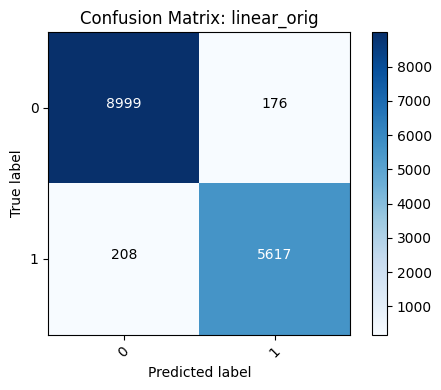


Model: rbf_orig
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9175
           1       0.97      0.96      0.97      5825

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



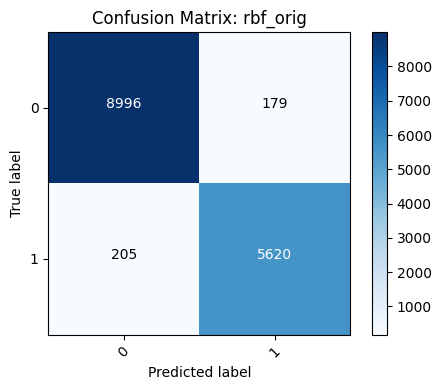


Model: rbf_pca95
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9175
           1       0.97      0.96      0.97      5825

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



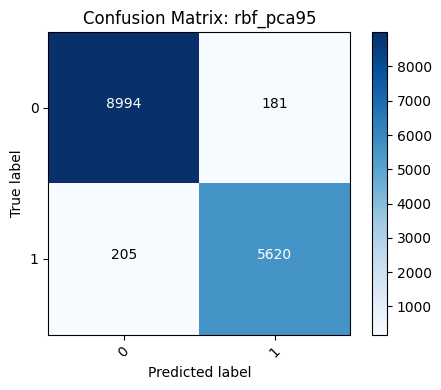


Model: rbf_pca2
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      9175
           1       0.96      0.95      0.96      5825

    accuracy                           0.97     15000
   macro avg       0.97      0.96      0.96     15000
weighted avg       0.97      0.97      0.97     15000



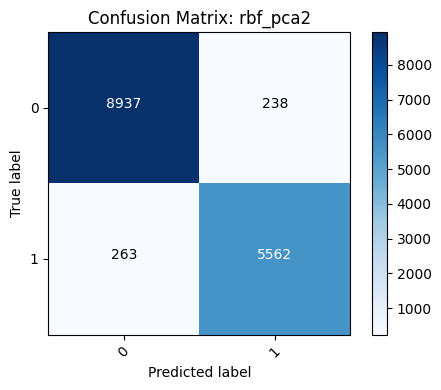

In [9]:
def plot_confusion(cm, classes, title="Confusion matrix"):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

# Show detailed results for each model
for name, model in svm_configs.items():
    Xtr, Xte = get_data_for_key(name)
    y_pred = model.predict(Xte)
    print("\n" + "="*60)
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    plot_confusion(cm, class_names, title=f"Confusion Matrix: {name}")
    plt.show()

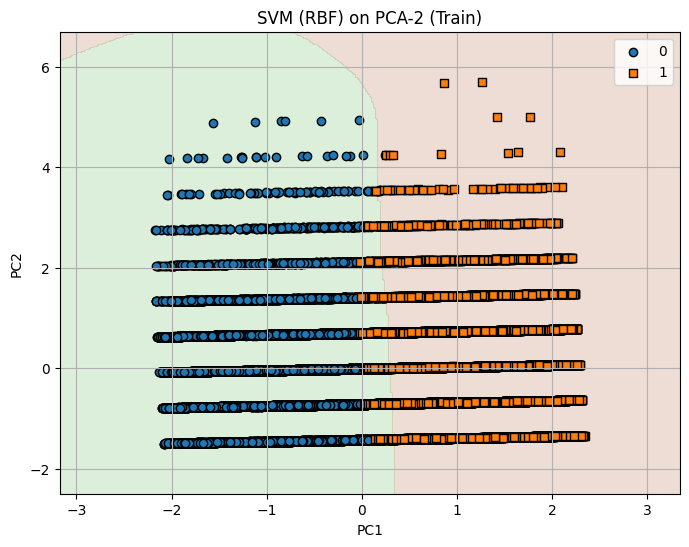

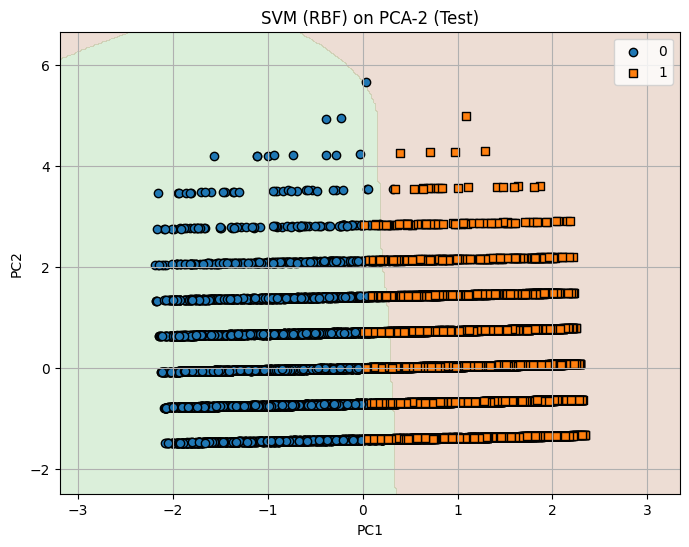

In [10]:
# Decision boundary helper
def plot_decision_boundary_2d(model, X2, y_true, title="Decision boundary (2D)"):
    # X2 assumed to be 2D (n_samples x 2)
    x_min, x_max = X2[:, 0].min() - 1.0, X2[:, 0].max() + 1.0
    y_min, y_max = X2[:, 1].min() - 1.0, X2[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.2, levels=np.arange(-0.5, len(class_names)+0.5, 1), cmap=plt.cm.Set1)
    markers = ['o', 's', '^']
    for idx, label in enumerate(np.unique(y_true)):
        pts = X2[y_true==label]
        plt.scatter(pts[:,0], pts[:,1], marker=markers[idx], label=class_names[label], edgecolor='k')
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot train and test decision boundaries (on PCA-2 projection)
plot_decision_boundary_2d(svm_configs["rbf_pca2"], X_train_pca2, y_train, title="SVM (RBF) on PCA-2 (Train)")
plot_decision_boundary_2d(svm_configs["rbf_pca2"], X_test_pca2, y_test, title="SVM (RBF) on PCA-2 (Test)")

In [11]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
results_df_sorted

,model,accuracy,precision_macro,recall_macro,f1_macro,train_time_s,predict_time_s,n_features
0,linear_orig,0.974400,0.973513,0.972555,0.973029,10.313597,0.415977,8
1,rbf_orig,0.974400,0.973426,0.972649,0.973034,21.876021,2.505530,8
2,rbf_pca95,0.974267,0.973257,0.972540,0.972895,19.334004,2.749911,5
3,rbf_pca2,0.966600,0.965189,0.964455,0.964819,20.337905,3.053628,2


In [12]:
best = results_df_sorted.iloc[0]
print("Best model by accuracy:", best["model"])
print(f"Accuracy: {best['accuracy']:.4f}, F1(macro): {best['f1_macro']:.4f}, Train time: {best['train_time_s']:.4f}s, n_features: {best['n_features']}")
print("\nFull results:")
print(results_df_sorted.to_string(index=False))

Best model by accuracy: linear_orig
Accuracy: 0.9744, F1(macro): 0.9730, Train time: 10.3136s, n_features: 8

Full results:
      model  accuracy  precision_macro  recall_macro  f1_macro  train_time_s  predict_time_s  n_features
linear_orig  0.974400         0.973513      0.972555  0.973029     10.313597        0.415977           8
   rbf_orig  0.974400         0.973426      0.972649  0.973034     21.876021        2.505530           8
  rbf_pca95  0.974267         0.973257      0.972540  0.972895     19.334004        2.749911           5
   rbf_pca2  0.966600         0.965189      0.964455  0.964819     20.337905        3.053628           2
